# Heart Disease Prediction: End-to-End Machine Learning Pipeline

## 1. Data Loading and Initial Inspection
In this section, the clinical dataset is loaded, and an initial structural inspection is performed to check for missing values, data types, and duplicate records.

In [59]:
# NOTE: Plotly default renderer is set to "png" to ensure static visibility on GitHub.
# If running this notebook locally for interactive plots, comment out or skip this entire cell.
!pip install kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "png"

In [60]:
import pandas as pd

In [61]:
df = pd.read_csv("heart.csv")

In [62]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [63]:
df.shape

(918, 12)

In [64]:
# Check for duplicate rows
duplicates_values = df[df.duplicated()]
len(duplicates_values)

0

In [65]:
# Check for missing values
missing_Values = df.isnull().sum()
missing_Values

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [66]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [67]:
df.dtypes.value_counts()

,count
int64,6
object,5
float64,1


In [68]:
categorical_col = df.select_dtypes(include = ["object"]).columns.to_list()
numerical_col = df.select_dtypes(include = ["int64", "float64"]).columns.to_list()
if "HeartDisease" in numerical_col:
    numerical_col.remove("HeartDisease")

In [69]:
categorical_col

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [70]:
numerical_col

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

In [71]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## 2. Exploratory Data Analysis (EDA)
Before preprocessing the data, clinical distributions and target variable correlations are visualized. This step is crucial for identifying underlying patterns, such as the impact of biological sex, specific chest pain types, and ECG abnormalities on the prevalence of heart disease.

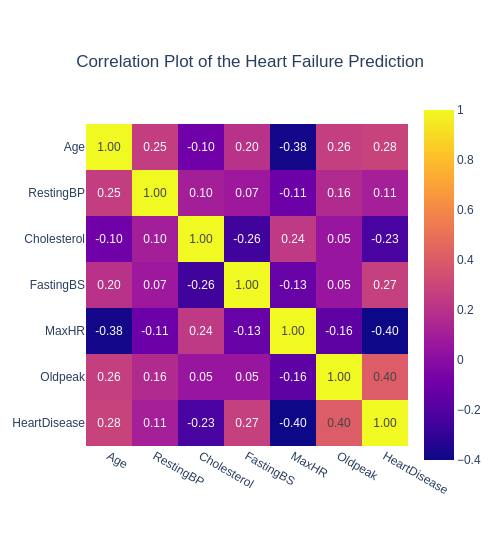

In [72]:
import plotly.express as px

fig = px.imshow(
    df.corr(numeric_only=True),
    title="Correlation Plot of the Heart Failure Prediction",
    text_auto=".2f",
)

fig.update_layout(
    width = 500,
    height = 550,
    title_x =0.5,
    title_y = 0.9
)

fig.show()

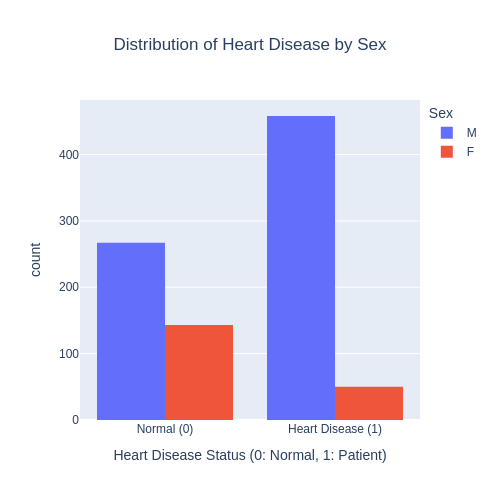

In [73]:
# Visualize the distribution of heart disease across biological sex
fig_sex_dist = px.histogram(
    df,
    x="HeartDisease",
    color="Sex",
    title="Distribution of Heart Disease by Sex",
    barmode="group",
    labels={
        "HeartDisease": "Heart Disease Status (0: Normal, 1: Patient)",
        "Sex": "Sex"
    }
)

fig_sex_dist.update_layout(
    title_x=0.5,
    width=500,
    height=500,
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1],
        ticktext=['Normal (0)', 'Heart Disease (1)']
    )
)

fig_sex_dist.show()

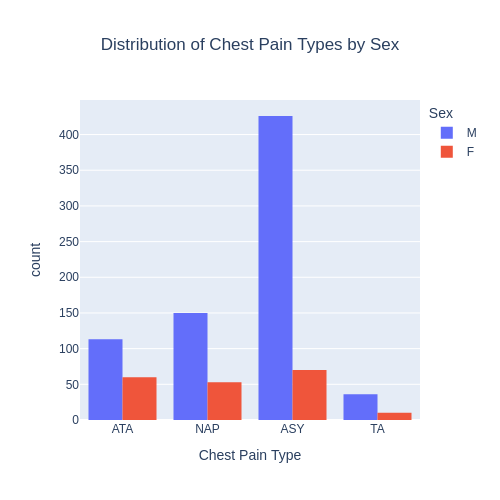

In [74]:
# Observe the relationship between specific chest pain types and heart disease
fig_chest_pain = px.histogram(
    df,
    x="ChestPainType",
    color="Sex",
    title="Distribution of Chest Pain Types by Sex",
    barmode="group",
    labels={
        "ChestPainType": "Chest Pain Type",
        "Sex": "Sex",
        "count": "Patient Count)"
    }
)

fig_chest_pain.update_layout(
    title_x=0.5,
    width=500,
    height=500
)

fig_chest_pain.show()

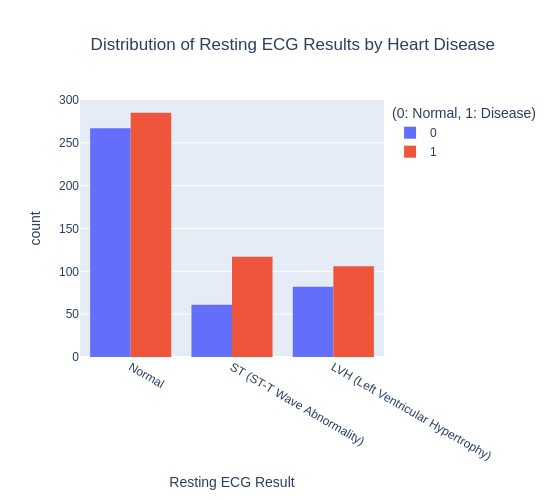

In [75]:
# Analyze resting electrocardiogram results partitioned by heart disease status
fig_resting_ecg = px.histogram(
    df,
    x="RestingECG",
    color="HeartDisease",
    title="Distribution of Resting ECG Results by Heart Disease",
    barmode="group",
    labels={
        "RestingECG": "Resting ECG Result",
        "HeartDisease": "(0: Normal, 1: Disease)",
        "count": "Patient Count (Hasta Sayısı)"
    }
)

fig_resting_ecg.update_layout(
    title_x=0.9,
    width=550,
    height=500,
    xaxis=dict(
        tickmode='array',
        tickvals=['Normal', 'LVH', 'ST'],
        ticktext=['Normal', 'LVH (Left Ventricular Hypertrophy)', 'ST (ST-T Wave Abnormality)']
    )
)

fig_resting_ecg.show()

## 3. Data Preprocessing
In this stage, physiological impossibilities within the dataset are addressed. Values of `0` in `Cholesterol` and `RestingBP` are treated as missing data (NaN) and imputed using the median of their respective `HeartDisease` classes. This targeted imputation prevents statistical distortion between healthy and patient profiles.

Additionally, although an IQR analysis detected 81 outliers, these instances are purposefully retained in the dataset. In medical contexts, such extreme values typically represent critical, high-risk patient conditions rather than measurement errors.

In [76]:
# Replace physiological impossibilities (0) with actual missing values (NaN)
import numpy as np

df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

print(f"Cholesterol eksik sayısı: {df["Cholesterol"].isnull().sum()}")
print(f"RestingBP eksik sayısı: {df["RestingBP"].isnull().sum()}")

# Impute missing values using the median of the respective HeartDisease class
df["Cholesterol"] = df.groupby("HeartDisease")["Cholesterol"].transform(
    lambda x: x.fillna(x.median())
)
df["RestingBP"] = df.groupby("HeartDisease")["RestingBP"].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values check after imputation:")
print(df[["Cholesterol", "RestingBP"]].isnull().sum())

Cholesterol eksik sayısı: 172
RestingBP eksik sayısı: 1

Missing values check after imputation:
Cholesterol    0
RestingBP      0
dtype: int64


In [77]:
# Exclude categorical/binary variables from IQR calculation
numerical_col = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

outliers_mask = pd.Series(False, index=df.index)
for col in numerical_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    columns_mask = ((df[col] < lower_limit) | (df[col] > upper_limit))
    outliers_mask = outliers_mask | columns_mask
    print(f"{col} - outlier count: {columns_mask.sum()}")

print(f"\nTotal outlier rows: {outliers_mask.sum()}")

Age - outlier count: 0
RestingBP - outlier count: 27
Cholesterol - outlier count: 41
MaxHR - outlier count: 2
Oldpeak - outlier count: 16

Total outlier rows: 81


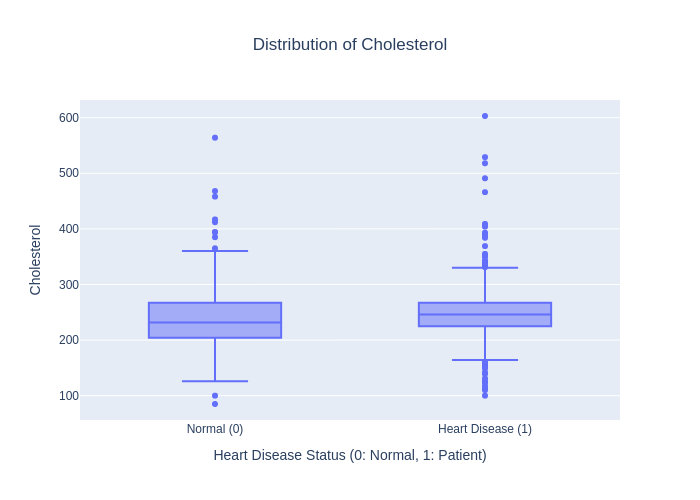

In [78]:
# Visualize cholesterol distribution by heart disease status to inspect outlier patterns
fig_cholesterol = px.box(
    df,
    y="Cholesterol",
    x="HeartDisease",
    title="Distribution of Cholesterol",
    labels={
        "HeartDisease": "Heart Disease Status (0: Normal, 1: Patient)"
        }
)

fig_cholesterol.update_layout(
    title_x=0.5,
    width=700,
    height=500,
    xaxis = dict(
        tickmode='array',
        tickvals=[0,1],
        ticktext=['Normal (0)', 'Heart Disease (1)']
    )
)

fig_cholesterol.show()

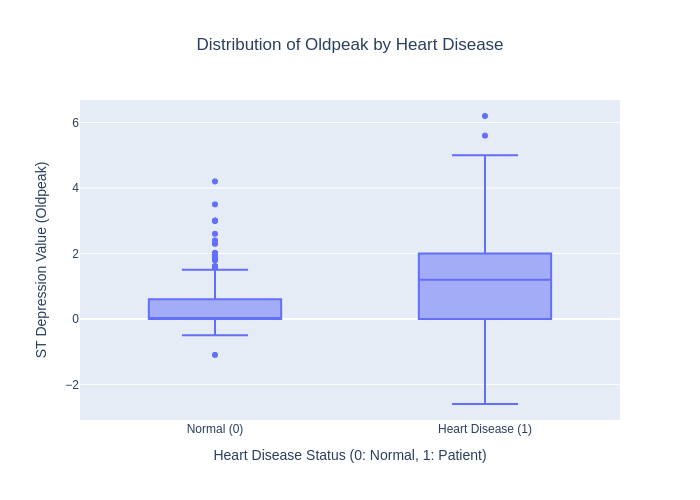

In [79]:
# Visualize ST depression (Oldpeak) distribution to evaluate high-risk clinical outliers
fig_oldpeak = px.box(
    df,
    x="HeartDisease",
    y="Oldpeak",
    title="Distribution of Oldpeak by Heart Disease",
    labels={
        "HeartDisease": "Heart Disease Status (0: Normal, 1: Patient)",
        "Oldpeak": "ST Depression Value (Oldpeak)"
    }
)
fig_oldpeak.update_layout(
    title_x=0.5,
    width=700,
    height=500,
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1],
        ticktext=['Normal (0)', 'Heart Disease (1)']
    )
)

fig_oldpeak.show()

## 4. Feature Engineering and Encoding
To help models capture non-linear patterns, domain-specific features are engineered. Specifically, `Age_Oldpeak_Interaction` is created by multiplying age and ST depression, reflecting a combined cardiac risk factor. Conversely, features showing weak correlation (such as `Cholesterol_Age_Ratio`) are dropped. Finally, categorical variables are encoded using One-Hot Encoding with `drop_first=True` to avoid the dummy variable trap.

In [80]:
# Create an interaction term for age and oldpeak as a combined risk signal
df["Age_Oldpeak_Interaction"] = df["Age"] * df["Oldpeak"]

# Test an experimental ratio feature
df["Cholesterol_Age_Ratio"] = df["Cholesterol"] / df["Age"]

correlations = df.corr(numeric_only=True)["HeartDisease"].sort_values(ascending=False)
print(f"\nCorrelations: \n{correlations}")

selected_features = correlations[abs(correlations) > 0.30].index.tolist()
selected_features.remove("HeartDisease")

print(f"Selected Features: {selected_features}")

# Drop features with very weak correlation to the target
df = df.drop(columns=["Cholesterol_Age_Ratio"])

print("\nFirst 5 rows after adding new features:")
df.head()


Correlations: 
HeartDisease               1.000000
Age_Oldpeak_Interaction    0.404260
Oldpeak                    0.403951
Age                        0.282039
FastingBS                  0.267291
RestingBP                  0.117909
Cholesterol                0.103784
Cholesterol_Age_Ratio     -0.094954
MaxHR                     -0.400421
Name: HeartDisease, dtype: float64
Selected Features: ['Age_Oldpeak_Interaction', 'Oldpeak', 'MaxHR']

First 5 rows after adding new features:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_Oldpeak_Interaction
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,0.0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,49.0
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,0.0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,72.0
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,0.0


In [81]:
y = df["HeartDisease"]
X = df.drop(columns= ["HeartDisease"])
X = pd.get_dummies(X, columns= ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"], drop_first= True, dtype= int)

print("\nFirst 5 rows after categorical encoding")
X.head()


First 5 rows after categorical encoding


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Age_Oldpeak_Interaction,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0.0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,49.0,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0.0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,72.0,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0.0,1,0,1,0,1,0,0,0,1


## 5. Model Training and Hyperparameter Optimization
To ensure reliable evaluation, the dataset is split into 80% training and 20% testing sets using the `stratify=y` parameter to preserve the class distribution of `HeartDisease`.

### Scaling Architecture and Pipeline
To prevent distance-based algorithms (`KNN`, `SVM`) and penalized linear models (Logistic Regression) from being biased by feature scales (e.g., `Cholesterol` vs. `Oldpeak`), standardization (`StandardScaler`) is applied. A `ColumnTransformer` is used to target only continuous features (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`, `Age_Oldpeak_Interaction`), leaving binary and one-hot encoded categorical columns unscaled.

To prevent data leakage during cross-validation, preprocessing and modeling steps are encapsulated within a `Pipeline`, ensuring that scaling parameters are computed strictly from each training fold.

### Hyperparameter Tuning via GridSearchCV
Five distinct algorithms (`Logistic Regression`, `KNN`, `SVM`, `Decision Tree`, `Random Forest`) are optimized using 5-fold `StratifiedKFold` and `GridSearchCV`. In alignment with our medical screening objective, the optimization metric (`scoring`) is strictly set to `f1` to maximize the model's stability in identifying high-risk patients without overlooking them.

In [82]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("--- Dataset Split Ratios ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Target Distribution in y_train (Patient/Normal):\n{y_train.value_counts(normalize=True)}")
print(f"Target Distribution in y_test (Patient/Normal):\n{y_test.value_counts(normalize=True)}")

--- Dataset Split Ratios ---
X_train shape: (734, 16)
X_test shape: (184, 16)
Target Distribution in y_train (Patient/Normal):
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64
Target Distribution in y_test (Patient/Normal):
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [83]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer

# Define continuous features for scaling
continuous_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "Age_Oldpeak_Interaction"]

# Scale only continuous features, leave binary/categorical columns as passthrough
preprocessor = ColumnTransformer([("scale", StandardScaler(), continuous_features)], remainder="passthrough")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_and_params = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        "grid_params": {
            "model__C": [0.01, 0.1, 1, 10, 100],
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"]
        }
    },
    "KNN": {
        "pipeline": Pipeline([
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier())
        ]),
        "grid_params": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 13],
            "model__metric": ["euclidean", "manhattan"],
            "model__weights": ["uniform", "distance"]
        }
    },
    "SVM": {
        "pipeline": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True, random_state=42))  # probability=True, ROC-AUC için gerekli
        ]),
       "grid_params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "grid_params": {
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_split": [2, 4, 6, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__criterion": ["gini", "entropy"]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "grid_params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, 15, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        }
    }

 }

In [84]:
results = []

fitted_models = {}  # Store the best grid search estimators for later interpretability (Feature Importance, Confusion Matrix)

for model_name, item in models_and_params.items():

    grid_search = GridSearchCV(
        estimator=item["pipeline"],
        param_grid=item["grid_params"],
        cv=skf,
        scoring="f1",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    # Save the fitted grid search object for each model
    fitted_models[model_name] = grid_search
    y_pred = grid_search.best_estimator_.predict(X_test)
    y_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]  #required for ROC-AUC calculation

    results.append({
        "model": model_name,
        "cv_best_f1": round(grid_search.best_score_, 4),
        "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
        "test_precision": round(precision_score(y_test, y_pred), 4),
        "test_recall": round(recall_score(y_test, y_pred), 4),
        "test_f1": round(f1_score(y_test, y_pred), 4),
        "test_roc_auc": round(roc_auc_score(y_test, y_proba), 4),
        "best_parameter_set": str(grid_search.best_params_)

    })

result_df = pd.DataFrame(results)
result_df

,model,cv_best_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,best_parameter_set
0,Logistic Regression,0.8712,0.8750,0.8911,0.8824,0.8867,0.9328,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
1,KNN,0.8820,0.8804,0.9082,0.8725,0.8900,0.9316,"{'model__metric': 'manhattan', 'model__n_neigh..."
2,SVM,0.8779,0.8587,0.8725,0.8725,0.8725,0.9329,"{'model__C': 1, 'model__gamma': 'scale', 'mode..."
3,Decision Tree,0.8433,0.7772,0.7961,0.8039,0.8000,0.8210,"{'model__criterion': 'gini', 'model__max_depth..."
4,Random Forest,0.8840,0.8641,0.8812,0.8725,0.8768,0.9328,"{'model__criterion': 'gini', 'model__max_depth..."


## 6. Model Comparison and Final Model Selection
After hyperparameter optimization, the unseen test set performance of all algorithms is evaluated across multiple metrics (`Accuracy`, `Precision`, `Recall`, `F1-Score`, and `ROC-AUC`). To assess generalizability and prevent overfitting, the Cross-Validation F1 score (`cv_best_f1`) is also included.

Although `Logistic Regression`, `SVM`, and `Random Forest` achieve comparable `ROC-AUC` scores (~0.93), `Random Forest` is selected as the final model based on its superior and stable `cv_best_f1` score (0.8840). Furthermore, the close alignment between cross-validation and test set scores demonstrates strong resistance to overfitting, making it robust for clinical screening.

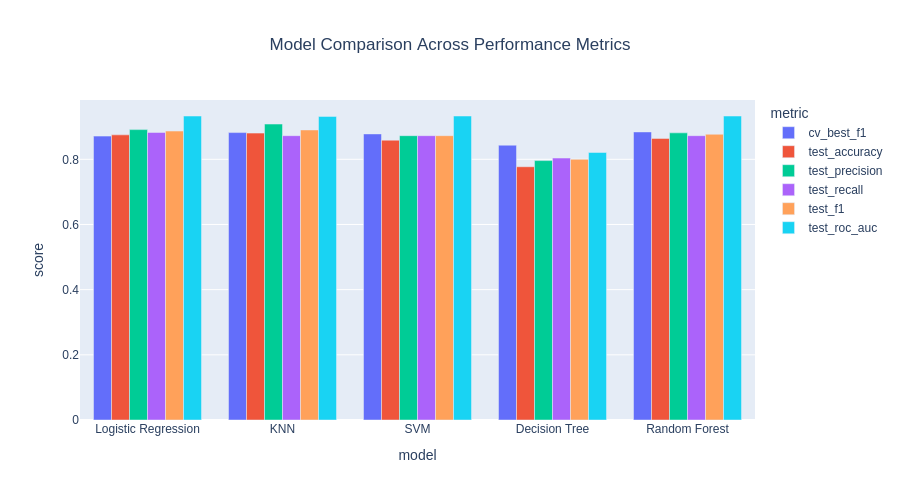

In [85]:
# Melt the result dataframe to prepare multi-metric group bar plotting via Plotly
metrics_to_plot= result_df.melt(
    id_vars="model",
    value_vars=["cv_best_f1", "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"],
    var_name="metric",
    value_name="score"
)

# Visualize and compare all performance metrics across the 5 optimized models
fig = px.bar(
    metrics_to_plot,
    x="model",
    y="score",
    color="metric",
    barmode="group",
    title="Model Comparison Across Performance Metrics"
)
fig.update_layout(
    title_x=0.5,
    width=900,
    height=500
)

fig.show()

## 7. Model Interpretability and Error Analysis
To ensure transparency in critical sectors like healthcare, model interpretability is vital. Using `Feature Importance` from the optimized `Random Forest` model, we analyze which clinical features drive predictions most significantly.


--- Feature Importance (Random Forest) ---
                    feature  importance
15              ST_Slope_Up    0.176447
14            ST_Slope_Flat    0.131049
4                     MaxHR    0.093295
6   Age_Oldpeak_Interaction    0.092155
5                   Oldpeak    0.088021
13         ExerciseAngina_Y    0.083892
2               Cholesterol    0.079430
0                       Age    0.057610
1                 RestingBP    0.054883
7                     Sex_M    0.036272
8         ChestPainType_ATA    0.031906
9         ChestPainType_NAP    0.027270
3                 FastingBS    0.021591
11        RestingECG_Normal    0.010795
10         ChestPainType_TA    0.008941
12            RestingECG_ST    0.006443


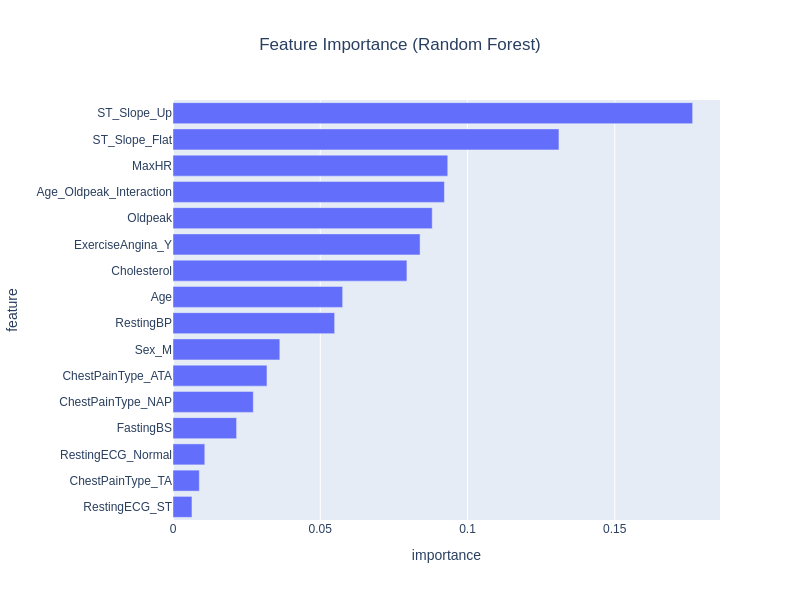

In [86]:
# Extract the best Random Forest model from the fitted GridSearchCV dictionary
best_rf_model = fitted_models["Random Forest"].best_estimator_.named_steps["model"]

# Create a dataframe pairing feature names with their importance scores
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n--- Feature Importance (Random Forest) ---")
print(importance_df)

# Visualize feature importances using a horizontal bar chart
fig = px.bar(
    importance_df, x="importance", y="feature", orientation="h",
    title="Feature Importance (Random Forest)"
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600, width=800, title_x =0.5)
fig.show()


## 8. Confusion Matrix and Clinical Error Analysis
To evaluate the model's performance on unseen test data, a Confusion Matrix and classification report are generated. Out of the test samples, 13 patients are falsely classified as healthy (False Negatives). This highlights that machine learning models should serve as screening and decision-support tools rather than standalone diagnostic replacements.

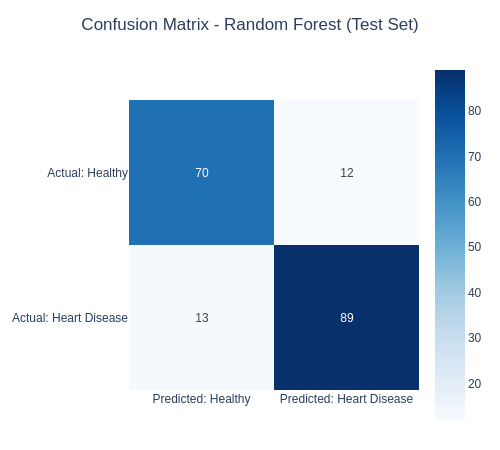

              precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [87]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the final Random Forest model
final_model = fitted_models["Random Forest"].best_estimator_
y_pred_final = final_model.predict(X_test)

# Generate confusion matrix values
cm = confusion_matrix(y_test, y_pred_final)

# Visualize confusion matrix heatmap using Plotly
fig = px.imshow(
                cm,
                text_auto=True,
                x=["Predicted: Healthy", "Predicted: Heart Disease"],
                y=["Actual: Healthy", "Actual: Heart Disease"],
                title="Confusion Matrix - Random Forest (Test Set)",
                color_continuous_scale="Blues")
fig.update_layout(
    width=500,
    height=450,
    margin=dict(l=20, r=20, t=60, b=20),
    title_x=0.5
)

fig.show()

# Print detailed classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred_final))